## Healthcare Synthetic Medical Diagnosis Record Generation Using CTGAN

### Project Domain
Healthcare

### Objective
To explore, clean, and preprocess the healthcare dataset before training a CTGAN model for synthetic medical diagnosis record generation.

### Dataset
Diabetes Prediction Dataset

#EDA & Data Preprocessing



In [221]:
#Import lib.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
print(sklearn.__version__)
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import warnings
warnings.filterwarnings("ignore")

1.6.1


In [222]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

In [223]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [224]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [225]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 100000
Columns : 9


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [227]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [228]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [229]:
df.duplicated().sum()

np.int64(3854)

In [230]:
df = df.drop_duplicates()

print(df.shape)

(96146, 9)


In [231]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("--------------------------------")

gender
['Female' 'Male' 'Other']
--------------------------------
age
[80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
--------------------------------
hypertension
[0 1]
--------------------------------
heart_disease
[1 0]
--------------------------------
smoking_history
['never' 'No Info' 'current' 'former' 'ever' 'not current']
--------------------------------
bmi
[25.19 27.32 23.45 ... 59.42 44.39 60.52]
-------------------------

#EDA

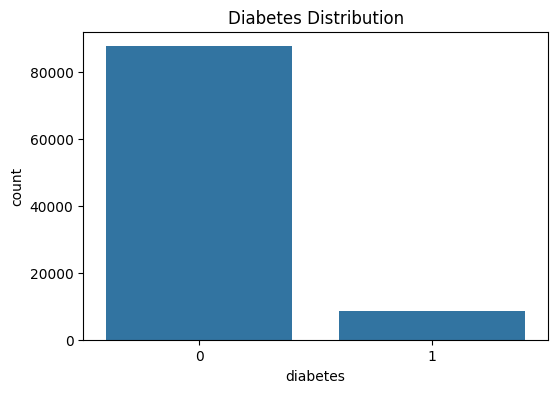

In [232]:
#Target Variable Count
plt.figure(figsize=(6,4))

sns.countplot(x='diabetes', data=df)

plt.title("Diabetes Distribution")

plt.show()

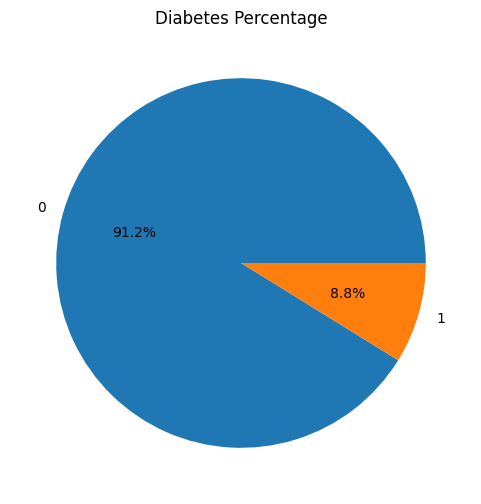

In [233]:
df['diabetes'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Diabetes Percentage")

plt.ylabel("")

plt.show()

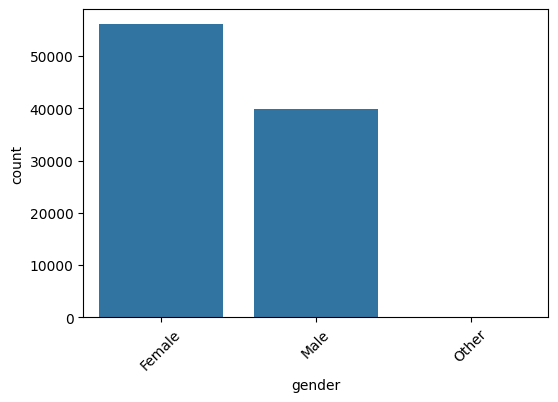

In [234]:
#Gender Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.xticks(rotation=45)

plt.show()

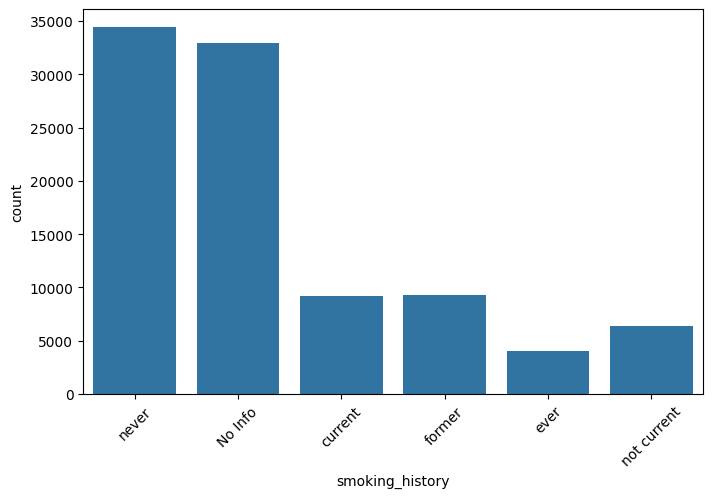

In [235]:
#Smoking History
plt.figure(figsize=(8,5))

sns.countplot(x='smoking_history', data=df)

plt.xticks(rotation=45)

plt.show()

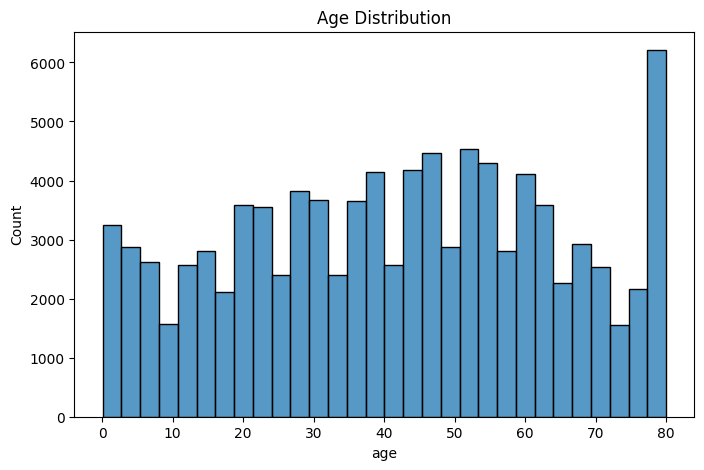

In [236]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")

plt.show()

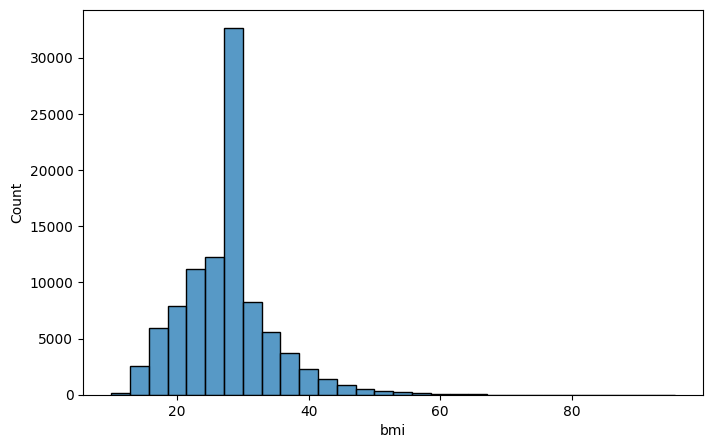

In [237]:
#BMI Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['bmi'], bins=30)

plt.show()

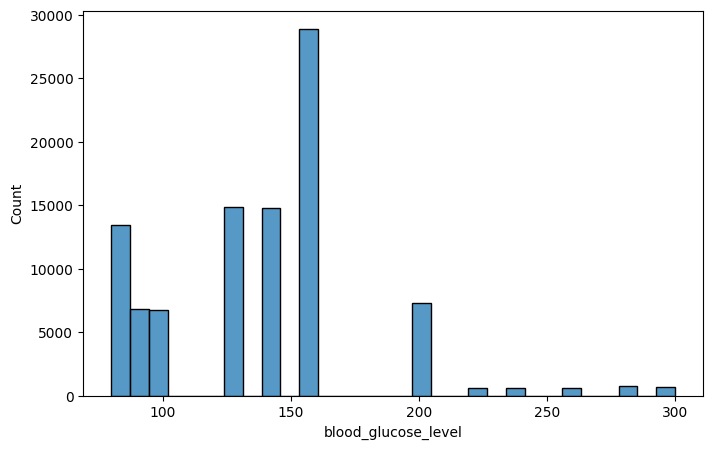

In [238]:
#Blood Glucose Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['blood_glucose_level'], bins=30)

plt.show()

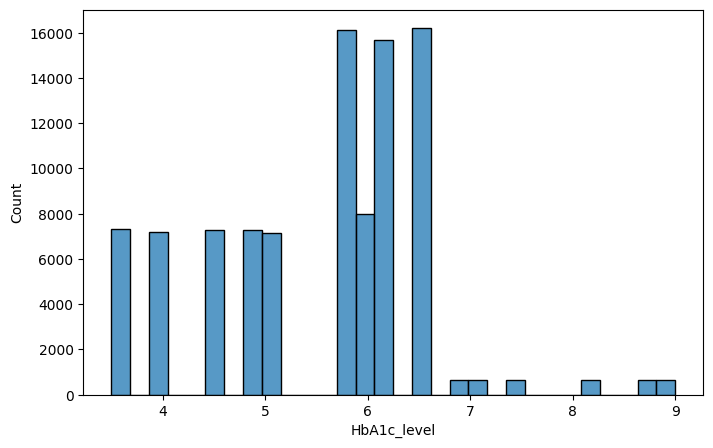

In [239]:
#HbA1c Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['HbA1c_level'], bins=30)

plt.show()

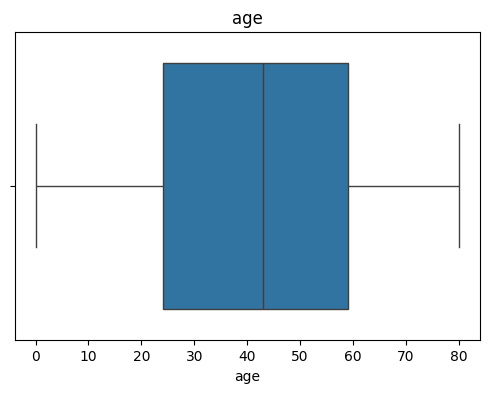

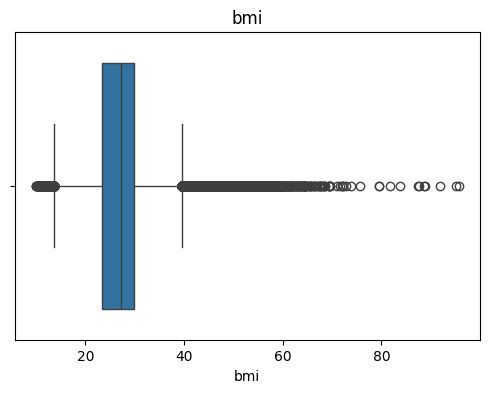

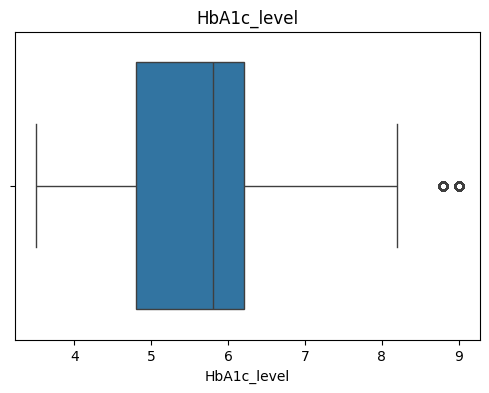

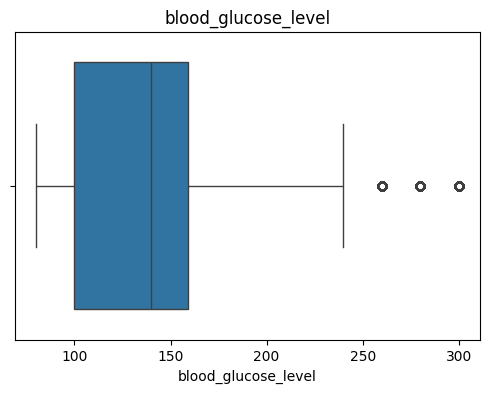

In [240]:
#Boxplots
numerical_columns = ['age','bmi','HbA1c_level','blood_glucose_level']
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [345]:
from sklearn.preprocessing import LabelEncoder
import joblib

gender_encoder = LabelEncoder()
smoking_encoder = LabelEncoder()

df["gender"] = gender_encoder.fit_transform(df["gender"])
df["smoking_history"] = smoking_encoder.fit_transform(df["smoking_history"])

joblib.dump(gender_encoder, "gender_encoder.pkl")
joblib.dump(smoking_encoder, "smoking_encoder.pkl")

print("Encoders saved successfully!")
print("Gender classes:", gender_encoder.classes_)
print("Smoking classes:", smoking_encoder.classes_)

Encoders saved successfully!
Gender classes: [0 1 2]
Smoking classes: [0 1 2 3 4 5]


In [343]:
from google.colab import files

files.download("gender_encoder.pkl")
files.download("smoking_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

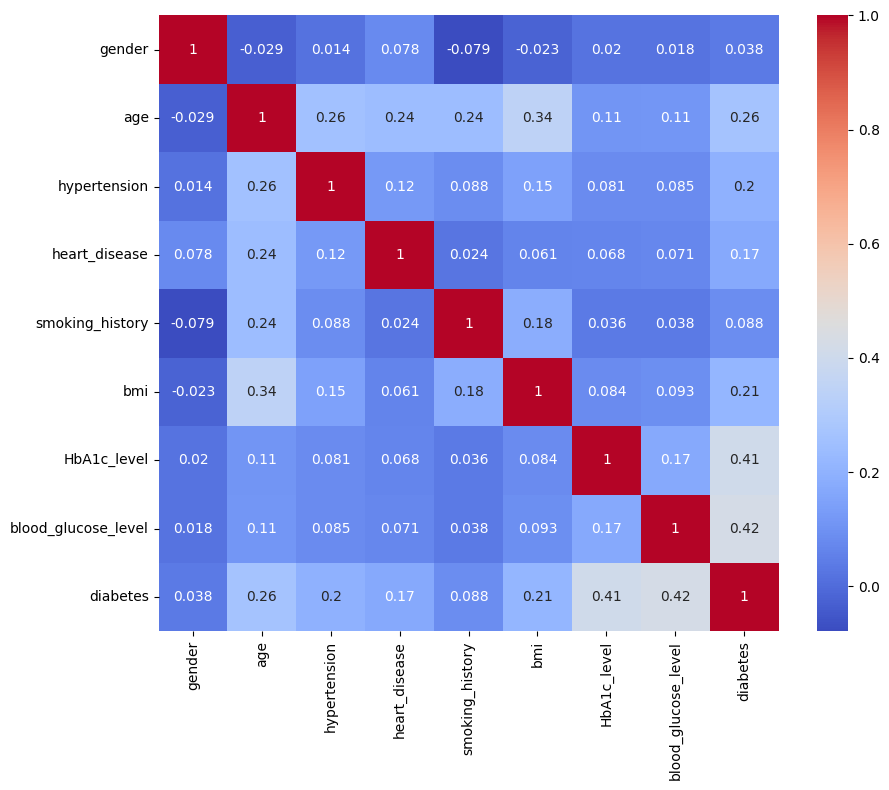

In [242]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

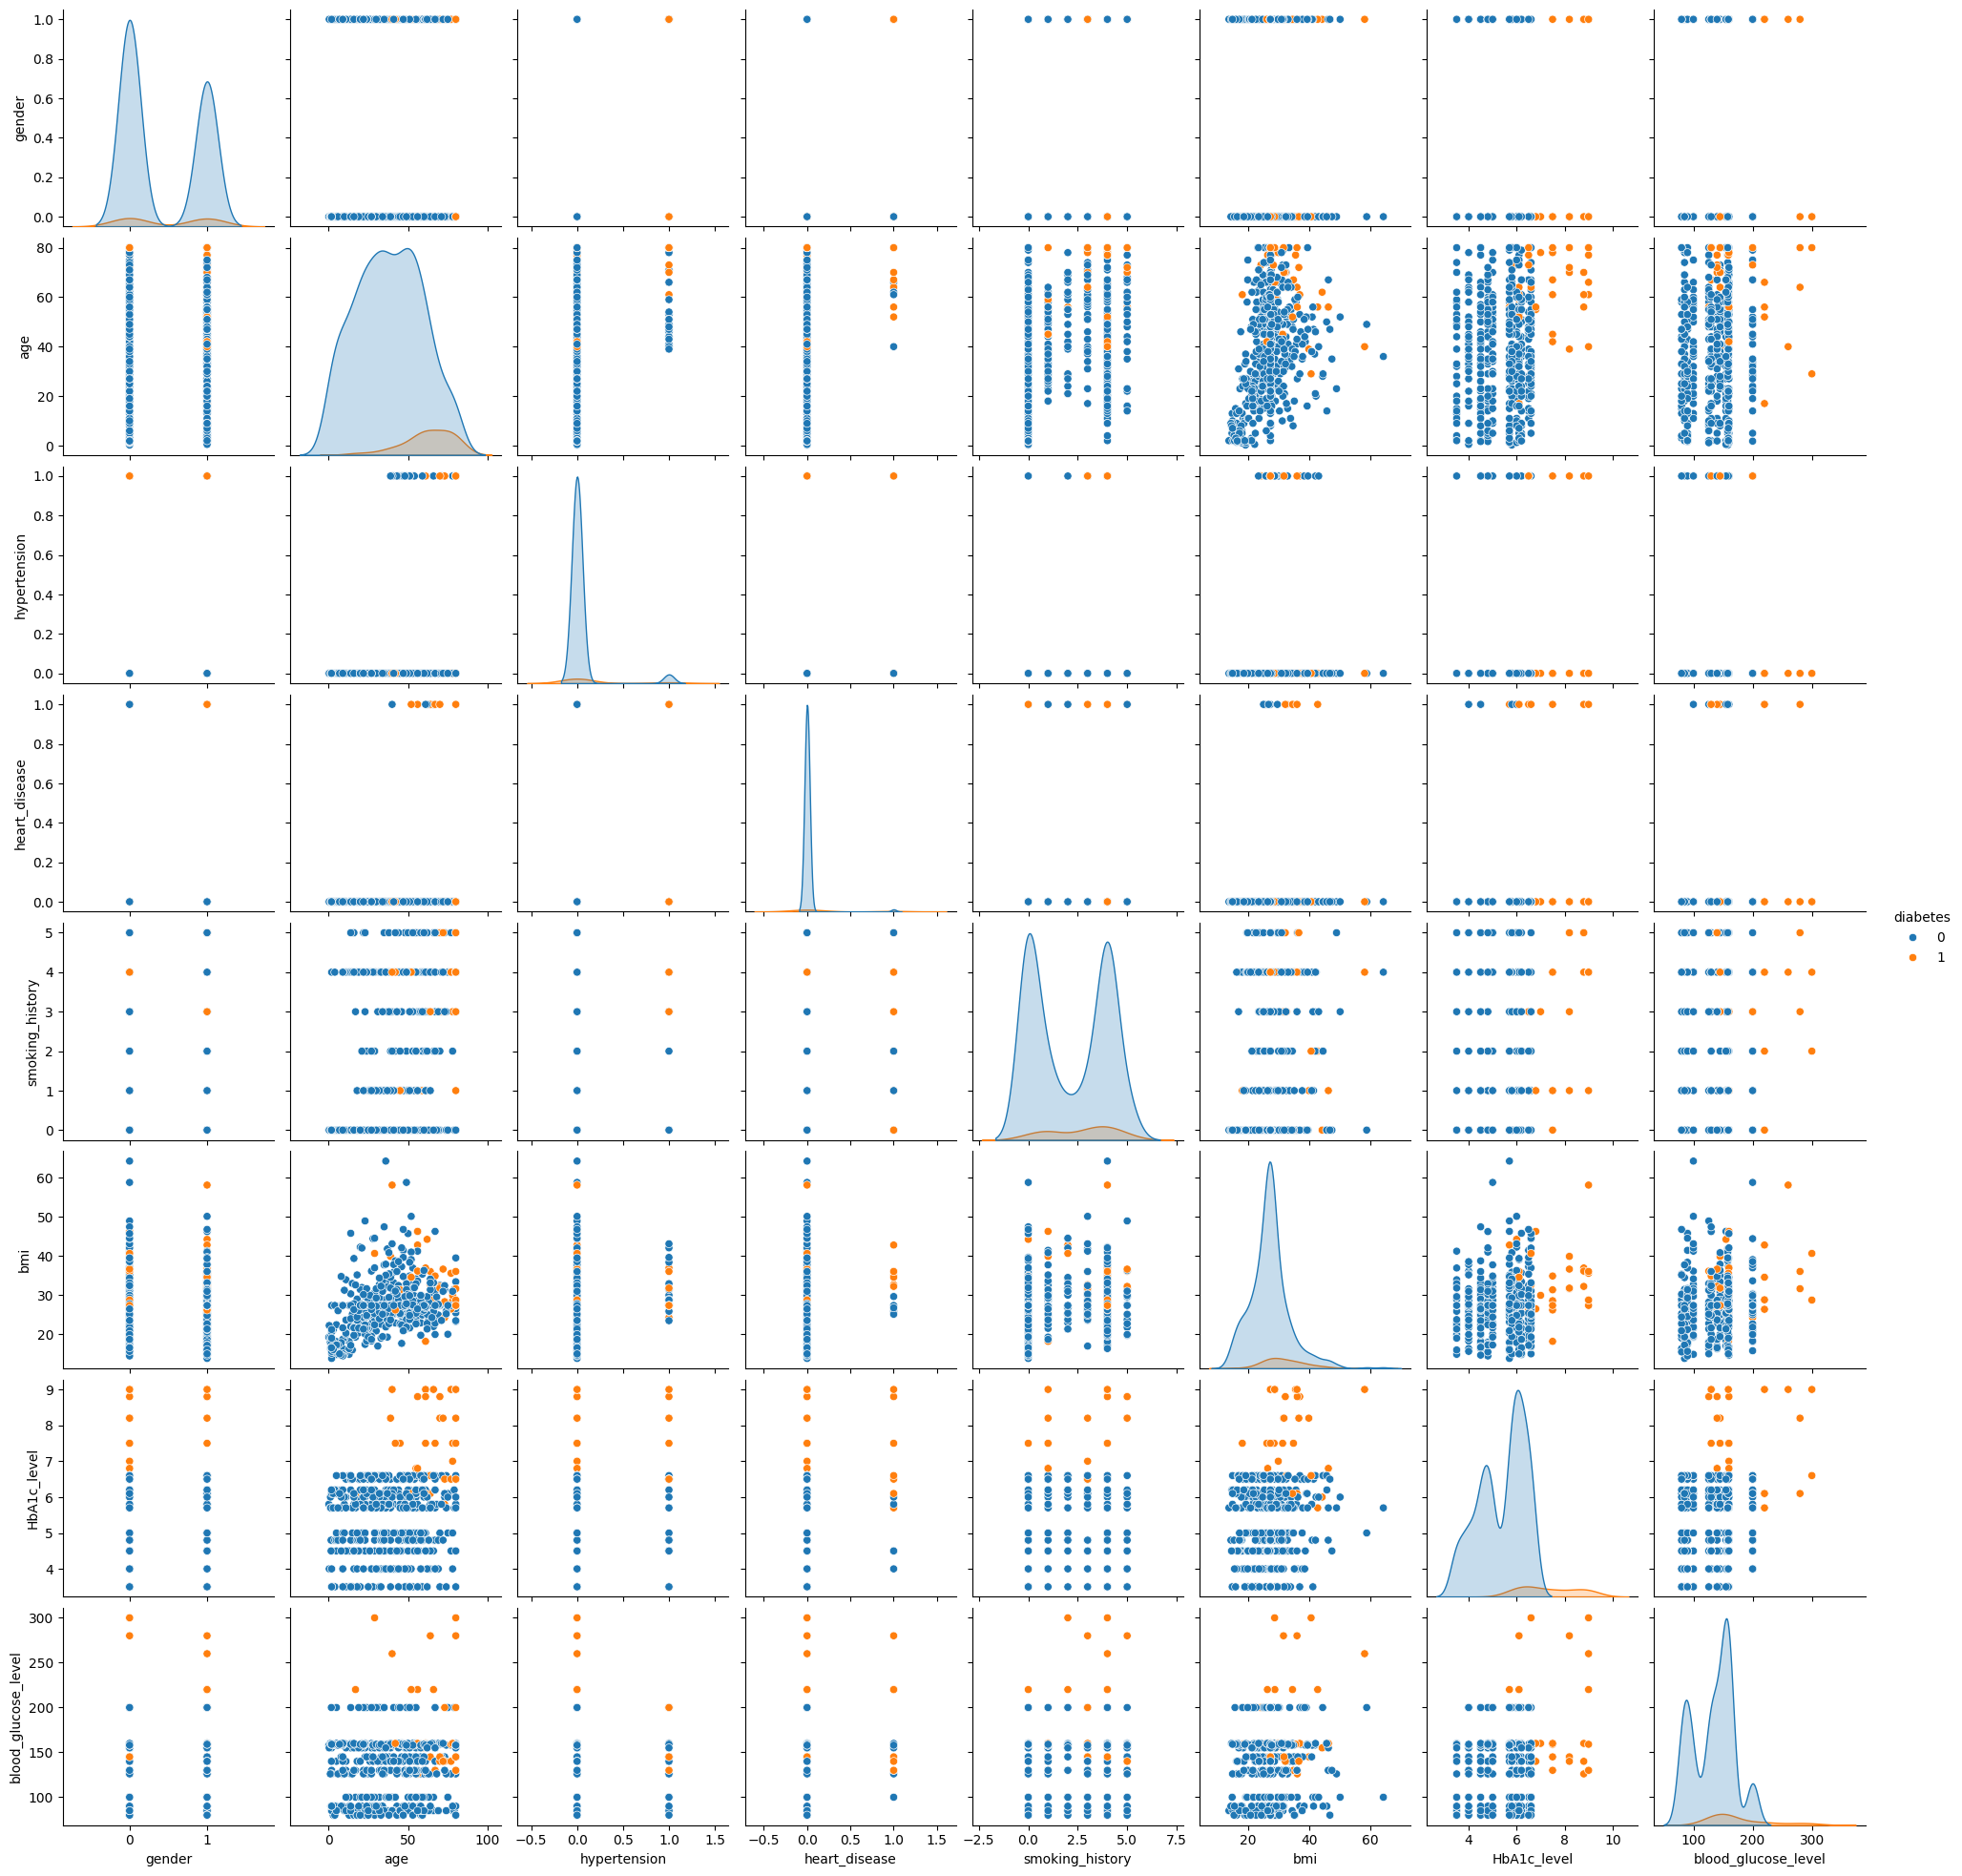

In [243]:
#Pairplot
sns.pairplot(df.sample(500), hue="diabetes")
plt.show()

In [244]:
# Feature Scaling
scaler = StandardScaler()

columns = ['age','bmi','HbA1c_level','blood_glucose_level']

df[columns] = scaler.fit_transform(df[columns])

import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [330]:
scaler = joblib.load("scaler.pkl")

In [328]:
!ls

age_distribution.png		 original_heatmap.png
augmented_dataset.csv		 PCA_plot.png
blood_glucose_distribution.png	 random_forest.pkl
bmi_distribution.png		 random_forest.pkl.gz
clean_diabetes_dataset.csv	 random_forest_standard.pkl
ctgan_model.pkl			 sample_data
diabetes_distribution.png	 scaler.pkl
diabetes_prediction_dataset.csv  streamlit_app.py
evaluation_summary.csv		 synthetic_heatmap.png
feature_importance.png		 synthetic_patient_data.csv
hba1c_distribution.png		 tsne_plot.png


In [245]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [246]:
#Save Clean Dataset
df.to_csv("clean_diabetes_dataset.csv",index=False)

#CTGAN Training & Synthetic Medical Data Generation

In [247]:
!pip install sdv


In [248]:
#Import Libraries
import pandas as pd
import numpy as np

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

import joblib

In [249]:
df = pd.read_csv("/content/clean_diabetes_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.314947,0.994563,0.043554,0
1,0,0.543372,0,0,0,-0.000216,0.994563,-1.423096,0
2,1,-0.614096,0,0,4,-0.000216,0.155970,0.483549,0
3,0,-0.257952,0,0,1,-0.572051,-0.496269,0.410216,0
4,1,1.522768,1,1,1,-1.061141,-0.682623,0.410216,0


In [250]:
print(df.shape)

(96146, 9)


In [251]:
#Create Metadata
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(df)

In [252]:
#View Metadata
metadata

{
    "columns": {
        "gender": {
            "sdtype": "categorical"
        },
        "age": {
            "sdtype": "numerical"
        },
        "hypertension": {
            "sdtype": "categorical"
        },
        "heart_disease": {
            "sdtype": "categorical"
        },
        "smoking_history": {
            "sdtype": "categorical"
        },
        "bmi": {
            "sdtype": "numerical"
        },
        "HbA1c_level": {
            "sdtype": "numerical"
        },
        "blood_glucose_level": {
            "sdtype": "numerical"
        },
        "diabetes": {
            "sdtype": "categorical"
        }
    },
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1"
}

In [253]:
#Create CTGAN Model
ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,
    verbose=True
)

In [254]:
#Train the CTGAN Model
ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=20,   # instead of 300
    verbose=True
)

In [255]:
#Save the Trained Model
joblib.dump(ctgan, "ctgan_model.pkl")

['ctgan_model.pkl']

In [259]:
#Display Synthetic Data
synthetic_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,0.761333,0,0,1,0.266945,0.569946,-1.423096,0
1,0,-0.441681,0,0,4,0.006689,-1.893114,-0.243405,0
2,0,-0.635564,0,0,0,0.719657,0.549675,-1.188172,0
3,0,0.773621,0,0,4,-0.864931,0.588173,-1.299649,0
4,1,1.146839,0,0,3,0.595632,1.110123,0.419917,1


In [260]:
#Check Shape
synthetic_data.shape

(5000, 9)

In [261]:
#Save Synthetic Dataset
synthetic_data.to_csv(
    "synthetic_patient_data.csv",
    index=False
)

In [262]:
#Compare Original vs Synthetic
print("Original Dataset")

display(df.head())

print("Synthetic Dataset")

display(synthetic_data.head())

Original Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.314947,0.994563,0.043554,0
1,0,0.543372,0,0,0,-0.000216,0.994563,-1.423096,0
2,1,-0.614096,0,0,4,-0.000216,0.155970,0.483549,0
3,0,-0.257952,0,0,1,-0.572051,-0.496269,0.410216,0
4,1,1.522768,1,1,1,-1.061141,-0.682623,0.410216,0


Synthetic Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,0.761333,0,0,1,0.266945,0.569946,-1.423096,0
1,0,-0.441681,0,0,4,0.006689,-1.893114,-0.243405,0
2,0,-0.635564,0,0,0,0.719657,0.549675,-1.188172,0
3,0,0.773621,0,0,4,-0.864931,0.588173,-1.299649,0
4,1,1.146839,0,0,3,0.595632,1.110123,0.419917,1


In [263]:
#Compare Statistics
print("Original")

display(df.describe())

print("Synthetic")

display(synthetic_data.describe())

Original


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,9.614600e+04,96146.000000,96146.000000,96146.000000,9.614600e+04,9.614600e+04,9.614600e+04,96146.000000
mean,0.416065,3.386211e-16,0.077601,0.040803,2.231159,-3.776416e-16,2.391484e-16,-7.419808e-17,0.088220
std,0.493287,1.000005e+00,0.267544,0.197833,1.879963,1.000005e+00,1.000005e+00,1.000005e+00,0.283616
min,0.000000,-1.857038e+00,0.000000,0.000000,0.000000,-2.557961e+00,-1.893923e+00,-1.423096e+00,0.000000
25%,0.000000,-7.921676e-01,0.000000,0.000000,0.000000,-5.794395e-01,-6.826227e-01,-9.342127e-01,0.000000
50%,0.000000,5.367419e-02,0.000000,0.000000,3.000000,-2.158954e-04,2.491471e-01,4.355386e-02,0.000000
75%,1.000000,7.659620e-01,0.000000,0.000000,4.000000,3.750973e-01,6.218550e-01,5.079930e-01,0.000000
max,2.000000,1.700840e+00,1.000000,1.000000,5.000000,1.010221e+01,3.230810e+00,3.954620e+00,1.000000


Synthetic


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.527400,0.146446,0.122200,0.103600,2.070200,0.032084,0.237137,0.120117,0.221600
std,0.539358,0.921071,0.327549,0.304771,1.898945,0.855260,1.197988,1.141982,0.415365
min,0.000000,-1.857038,0.000000,0.000000,0.000000,-2.057470,-1.893923,-1.423096,0.000000
25%,0.000000,-0.483844,0.000000,0.000000,0.000000,-0.542422,-0.942024,-0.926033,0.000000
50%,1.000000,0.127437,0.000000,0.000000,2.000000,0.000771,0.473492,0.049952,0.000000
75%,1.000000,0.914067,0.000000,0.000000,4.000000,0.462636,0.979804,0.505601,0.000000
max,2.000000,1.700840,1.000000,1.000000,5.000000,4.080852,3.230810,3.954620,1.000000


In [264]:
#Compare Missing Values
print(df.isnull().sum())

print(synthetic_data.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


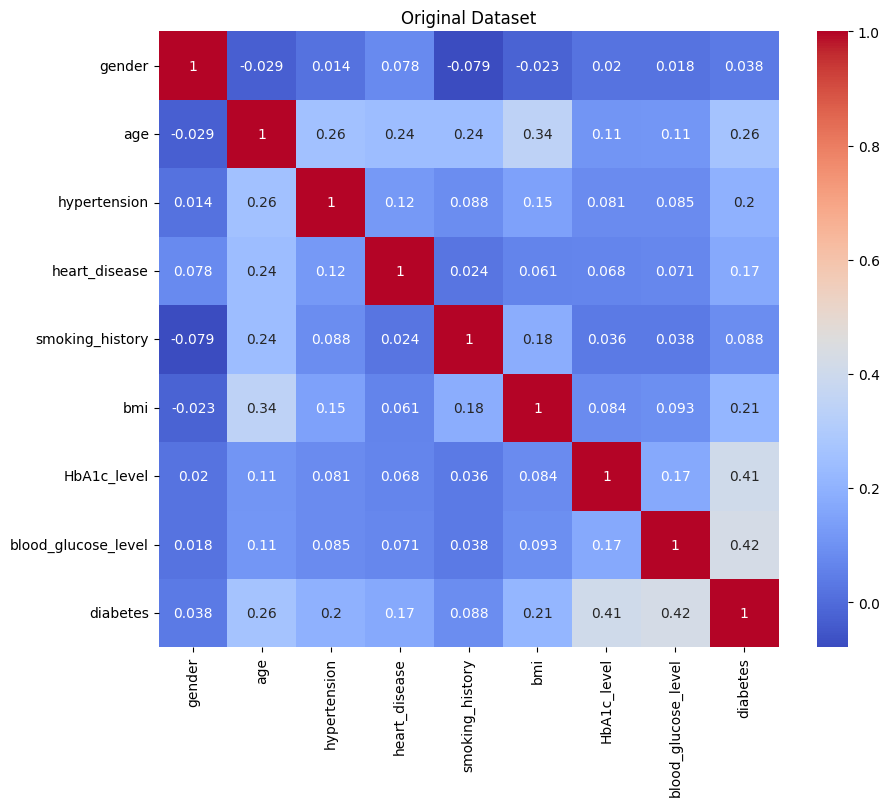

In [265]:
#Compare Correlation Heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Original Dataset")

plt.show()

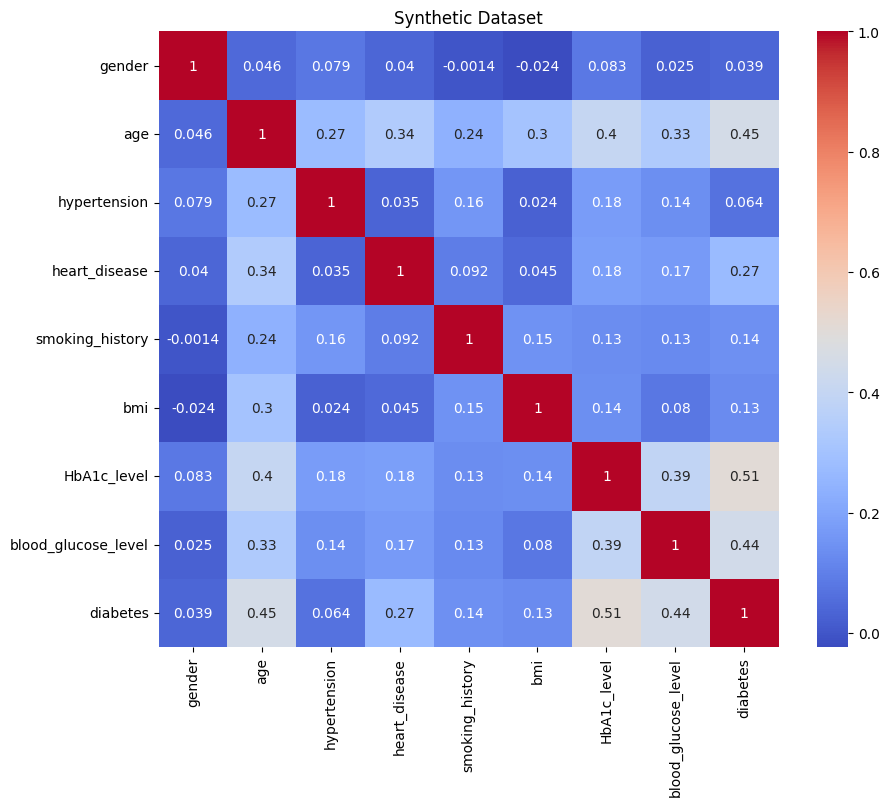

In [266]:
plt.figure(figsize=(10,8))

sns.heatmap(synthetic_data.corr(), annot=True, cmap="coolwarm")

plt.title("Synthetic Dataset")

plt.show()

In [267]:
#Download Files
from google.colab import files

files.download("synthetic_patient_data.csv")

files.download("ctgan_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Model Training (Original vs Augmented Dataset)

In [268]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import joblib

In [269]:
#Load Original Dataset
original_data = pd.read_csv("clean_diabetes_dataset.csv")

original_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.314947,0.994563,0.043554,0
1,0,0.543372,0,0,0,-0.000216,0.994563,-1.423096,0
2,1,-0.614096,0,0,4,-0.000216,0.155970,0.483549,0
3,0,-0.257952,0,0,1,-0.572051,-0.496269,0.410216,0
4,1,1.522768,1,1,1,-1.061141,-0.682623,0.410216,0


In [270]:
#Load Synthetic Dataset
synthetic_data = pd.read_csv("synthetic_patient_data.csv")

synthetic_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,0.761333,0,0,1,0.266945,0.569946,-1.423096,0
1,0,-0.441681,0,0,4,0.006689,-1.893114,-0.243405,0
2,0,-0.635564,0,0,0,0.719657,0.549675,-1.188172,0
3,0,0.773621,0,0,4,-0.864931,0.588173,-1.299649,0
4,1,1.146839,0,0,3,0.595632,1.110123,0.419917,1


In [271]:
#Check Dataset Shapes
print("Original Dataset Shape")
print(original_data.shape)

print()

print("Synthetic Dataset Shape")
print(synthetic_data.shape)

Original Dataset Shape
(96146, 9)

Synthetic Dataset Shape
(5000, 9)


In [272]:
#Merge Both Datasets
augmented_data = pd.concat(
    [original_data, synthetic_data],
    ignore_index=True
)

augmented_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.314947,0.994563,0.043554,0
1,0,0.543372,0,0,0,-0.000216,0.994563,-1.423096,0
2,1,-0.614096,0,0,4,-0.000216,0.155970,0.483549,0
3,0,-0.257952,0,0,1,-0.572051,-0.496269,0.410216,0
4,1,1.522768,1,1,1,-1.061141,-0.682623,0.410216,0


In [273]:
#Check Augmented Dataset Shape
print("Augmented Dataset Shape")

print(augmented_data.shape)

Augmented Dataset Shape
(101146, 9)


In [274]:
#Shuffle Dataset
augmented_data = augmented_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [275]:
#Save Augmented Dataset
augmented_data.to_csv(
    "augmented_dataset.csv",
    index=False
)

In [277]:
#Features & Target (Original Data)
X_original = original_data.drop("diabetes", axis=1)

y_original = original_data["diabetes"]

In [278]:
#Train-Test Split
X_train_org, X_test_org, y_train_org, y_test_org = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    random_state=42,
    stratify=y_original
)

In [279]:
#Train Random Forest (Original Dataset)
rf_original = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

rf_original.fit(
    X_train_org,
    y_train_org
)

RandomForestClassifier(max_depth=10, n_estimators=20, n_jobs=1, random_state=42)

In [280]:
#Predict
y_pred_org = rf_original.predict(X_test_org)

y_prob_org = rf_original.predict_proba(X_test_org)[:,1]

In [281]:
#Evaluation (Original Dataset)
print("Accuracy :", accuracy_score(y_test_org, y_pred_org))

print("Precision :", precision_score(y_test_org, y_pred_org))

print("Recall :", recall_score(y_test_org, y_pred_org))

print("F1 Score :", f1_score(y_test_org, y_pred_org))

print("ROC AUC :", roc_auc_score(y_test_org, y_prob_org))

Accuracy : 0.971866874674987
Precision : 1.0
Recall : 0.6810141509433962
F1 Score : 0.810242020343739
ROC AUC : 0.9691428183464579


In [282]:
#Classification Report
print(classification_report(
    y_test_org,
    y_pred_org
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.99      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



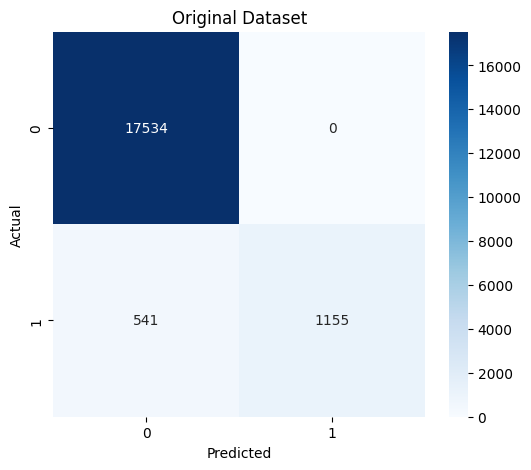

In [283]:
#Confusion Matrix
cm = confusion_matrix(
    y_test_org,
    y_pred_org
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Original Dataset")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

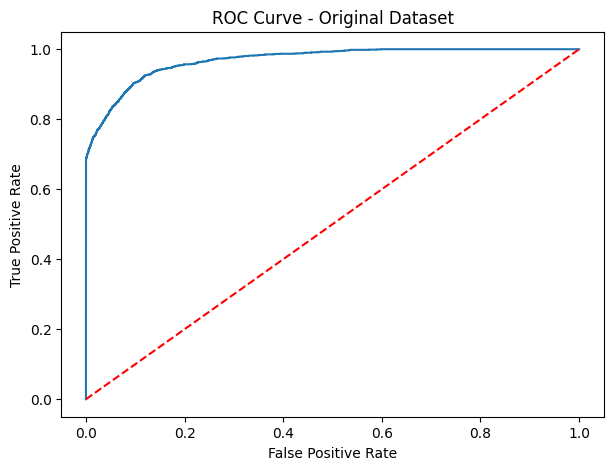

In [284]:
#ROC Curve
fpr, tpr, threshold = roc_curve(
    y_test_org,
    y_prob_org
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Original Dataset")

plt.show()

In [285]:
#Features & Target (Augmented Data)
X_aug = augmented_data.drop(
    "diabetes",
    axis=1
)

y_aug = augmented_data["diabetes"]

In [286]:
# Remove rows with NaN values from y_aug and corresponding rows from X_aug
# Identify rows where 'diabetes' (y_aug) is not NaN
non_nan_mask = y_aug.notna()
X_aug = X_aug[non_nan_mask]
y_aug = y_aug[non_nan_mask]

#Train-Test Split
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug,
    y_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_aug
)

In [287]:
#Train Random Forest (Augmented Dataset)
rf_augmented = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

rf_augmented.fit(
    X_train_aug,
    y_train_aug
)

RandomForestClassifier(max_depth=10, n_estimators=20, n_jobs=1, random_state=42)

In [288]:
# Save the trained model

import joblib
import pickle

# Existing model file
joblib.dump(rf_augmented,"random_forest.pkl",compress=3)
# New standard pickle model file
with open("random_forest_standard.pkl", "wb") as f:
    pickle.dump(rf_augmented, f)
print(type(model))
print("Both model files saved successfully!")

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Both model files saved successfully!


In [331]:
import joblib

model = joblib.load("random_forest_standard.pkl")
scaler = joblib.load("scaler.pkl")

In [289]:
from google.colab import files

files.download("random_forest_standard.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [290]:
#Prediction
# The model rf_augmented was not fitted before this cell was executed,
# leading to a NotFittedError.
# We will fit the model here to ensure it's ready for prediction.
if not hasattr(rf_augmented, 'classes_'):
    rf_augmented.fit(X_train_aug, y_train_aug)

y_pred_aug = rf_augmented.predict(X_test_aug)

y_prob_aug = rf_augmented.predict_proba(X_test_aug)[:,1]

In [291]:
#Evaluation
print("Accuracy :", accuracy_score(y_test_aug, y_pred_aug))

print("Precision :", precision_score(y_test_aug, y_pred_aug))

print("Recall :", recall_score(y_test_aug, y_pred_aug))

print("F1 Score :", f1_score(y_test_aug, y_pred_aug))

print("ROC AUC :", roc_auc_score(y_test_aug, y_prob_aug))

Accuracy : 0.9664359861591696
Precision : 0.9747126436781609
Recall : 0.6631908237747653
F1 Score : 0.78932671424139
ROC AUC : 0.967681380460843


In [292]:
#Classification Report
print(classification_report(
    y_test_aug,
    y_pred_aug
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18312
           1       0.97      0.66      0.79      1918

    accuracy                           0.97     20230
   macro avg       0.97      0.83      0.89     20230
weighted avg       0.97      0.97      0.96     20230



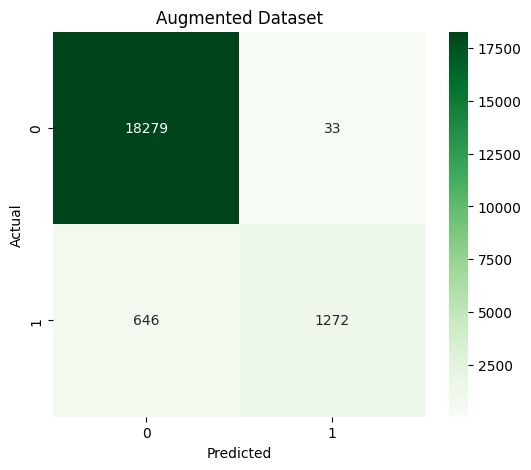

In [293]:
#Confusion Matrix
cm = confusion_matrix(
    y_test_aug,
    y_pred_aug
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Augmented Dataset")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

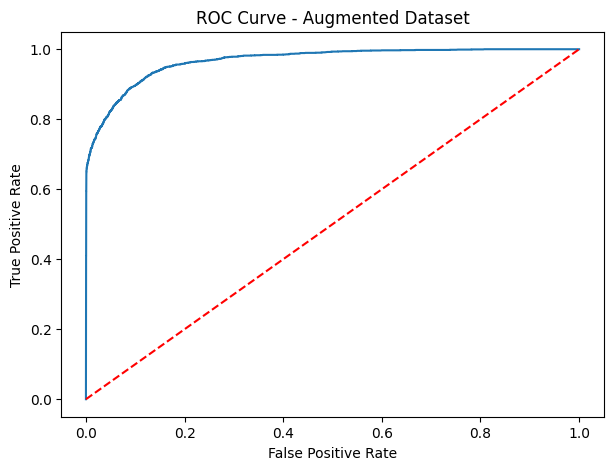

In [294]:
#ROC Curve
fpr, tpr, threshold = roc_curve(
    y_test_aug,
    y_prob_aug
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Augmented Dataset")

plt.show()

In [295]:
#Compare Results
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Original":[
        accuracy_score(y_test_org,y_pred_org),
        precision_score(y_test_org,y_pred_org),
        recall_score(y_test_org,y_pred_org),
        f1_score(y_test_org,y_pred_org),
        roc_auc_score(y_test_org,y_prob_org)
    ],

    "Augmented":[
        accuracy_score(y_test_aug,y_pred_aug),
        precision_score(y_test_aug,y_pred_aug),
        recall_score(y_test_aug,y_pred_aug),
        f1_score(y_test_aug,y_pred_aug),
        roc_auc_score(y_test_aug,y_prob_aug)
    ]

})

results

,Metric,Original,Augmented
0,Accuracy,0.971867,0.966436
1,Precision,1.000000,0.974713
2,Recall,0.681014,0.663191
3,F1 Score,0.810242,0.789327
4,ROC AUC,0.969143,0.967681


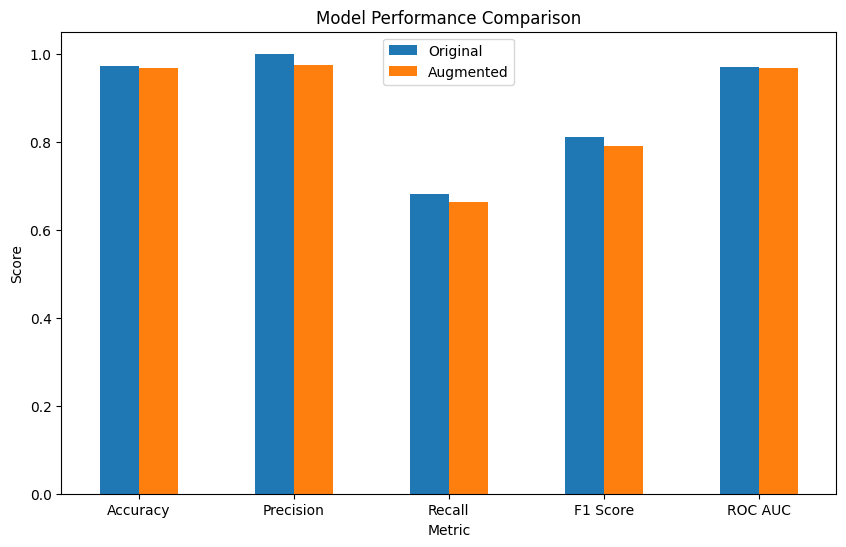

In [296]:
#Plot Comparison
results.set_index("Metric").plot(kind="bar",figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [297]:
#Feature Importance
importance = pd.DataFrame({"Feature":X_aug.columns,"Importance":rf_augmented.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)

importance

,Feature,Importance
6,HbA1c_level,0.509298
7,blood_glucose_level,0.366676
1,age,0.051043
5,bmi,0.030294
2,hypertension,0.022946
3,heart_disease,0.012966
4,smoking_history,0.004927
0,gender,0.001850


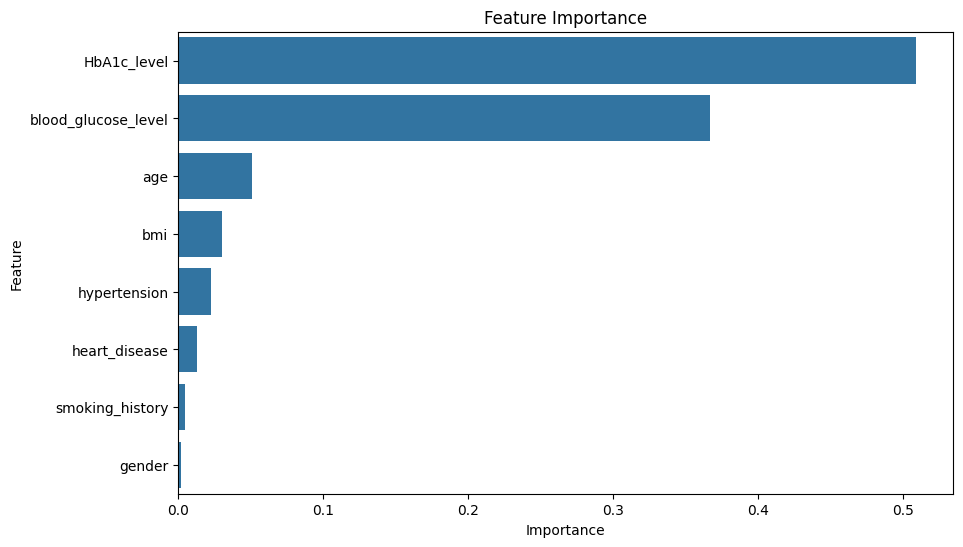

In [298]:
#Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance")
plt.show()

In [299]:
#Save Model
joblib.dump(rf_augmented,"random_forest.pkl")

['random_forest.pkl']

In [300]:
import pickle

# Save model in standard pickle format
with open("random_forest_standard.pkl", "wb") as f:
    pickle.dump(rf_augmented, f)

print("Model saved successfully!")

# Download files
from google.colab import files

files.download("random_forest_standard.pkl")
files.download("augmented_dataset.csv")

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Evaluation & Visualization

In [301]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import joblib

In [302]:
#Load Datasets
original = pd.read_csv("clean_diabetes_dataset.csv")

synthetic = pd.read_csv("synthetic_patient_data.csv")

augmented = pd.read_csv("augmented_dataset.csv")

In [303]:
#Check Shapes
print("Original :", original.shape)

print("Synthetic :", synthetic.shape)

print("Augmented :", augmented.shape)

Original : (96146, 9)
Synthetic : (5000, 9)
Augmented : (101146, 9)


In [304]:
#Display First Five Rows
print("Original Dataset")
display(original.head())
print("Synthetic Dataset")
display(synthetic.head())

Original Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.314947,0.994563,0.043554,0
1,0,0.543372,0,0,0,-0.000216,0.994563,-1.423096,0
2,1,-0.614096,0,0,4,-0.000216,0.155970,0.483549,0
3,0,-0.257952,0,0,1,-0.572051,-0.496269,0.410216,0
4,1,1.522768,1,1,1,-1.061141,-0.682623,0.410216,0


Synthetic Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,0.761333,0,0,1,0.266945,0.569946,-1.423096,0
1,0,-0.441681,0,0,4,0.006689,-1.893114,-0.243405,0
2,0,-0.635564,0,0,0,0.719657,0.549675,-1.188172,0
3,0,0.773621,0,0,4,-0.864931,0.588173,-1.299649,0
4,1,1.146839,0,0,3,0.595632,1.110123,0.419917,1


In [305]:
#Statistical Comparison
comparison = pd.DataFrame({"Original Mean":original.mean(),"Synthetic Mean":synthetic.mean()})
comparison

,Original Mean,Synthetic Mean
gender,4.160652e-01,0.527400
age,3.386211e-16,0.146446
hypertension,7.760073e-02,0.122200
heart_disease,4.080253e-02,0.103600
smoking_history,2.231159e+00,2.070200
bmi,-3.776416e-16,0.032084
HbA1c_level,2.391484e-16,0.237137
blood_glucose_level,-7.419808e-17,0.120117
diabetes,8.822000e-02,0.221600


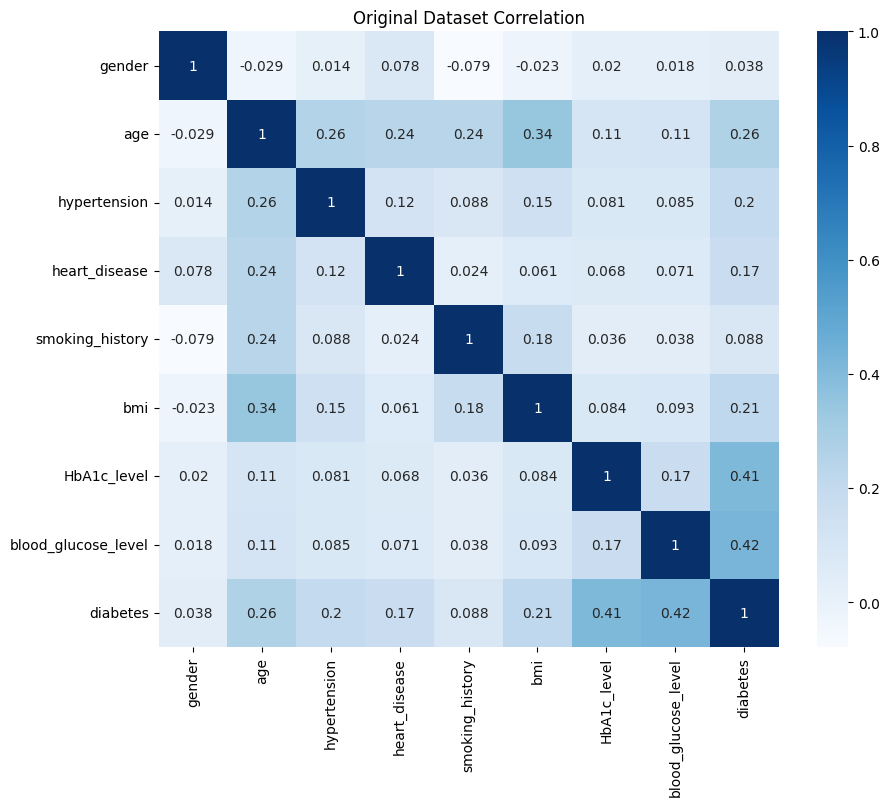

In [306]:
#Correlation Heatmap (Original)
plt.figure(figsize=(10,8))
sns.heatmap(original.corr(),annot=True,cmap="Blues")
plt.title("Original Dataset Correlation")
plt.savefig("original_heatmap.png")
plt.show()

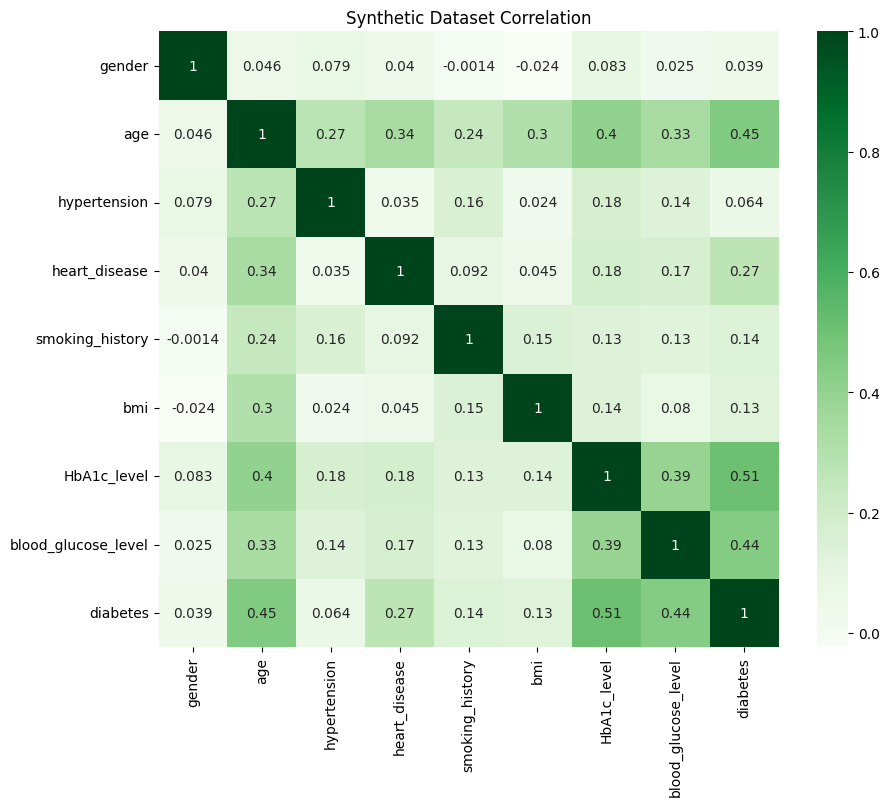

In [307]:
#Correlation Heatmap (Synthetic)
plt.figure(figsize=(10,8))
sns.heatmap(synthetic.corr(),annot=True,cmap="Greens")
plt.title("Synthetic Dataset Correlation")
plt.savefig("synthetic_heatmap.png")
plt.show()

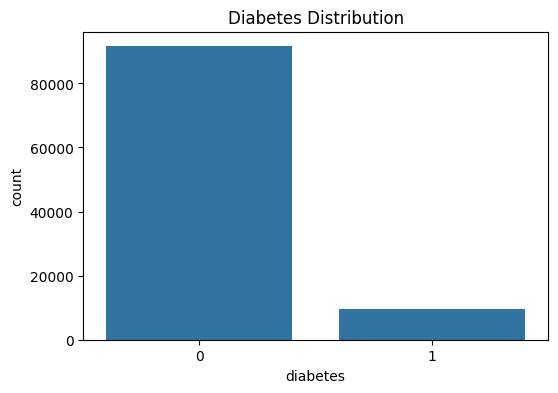

In [308]:
#Diabetes Distribution
plt.figure(figsize=(6,4))

sns.countplot(x="diabetes",data=augmented)
plt.title("Diabetes Distribution")
plt.savefig("diabetes_distribution.png")
plt.show()

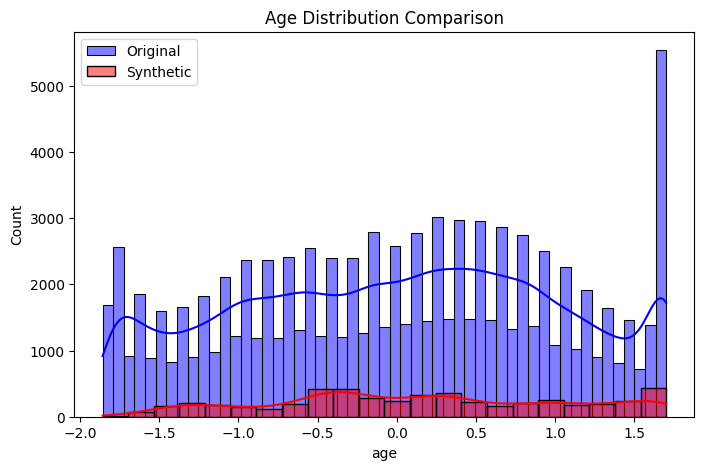

In [309]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["age"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["age"],color="red",label="Synthetic",kde=True)
plt.legend()
plt.title("Age Distribution Comparison")
plt.savefig("age_distribution.png")
plt.show()

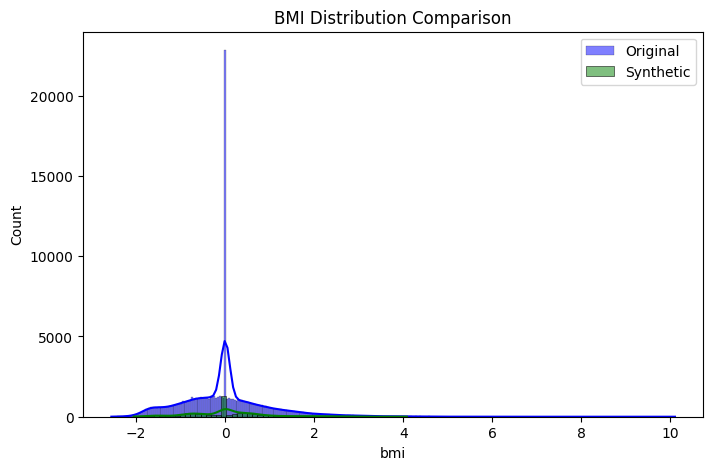

In [310]:
#BMI Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["bmi"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["bmi"],color="green",label="Synthetic",kde=True)
plt.legend()
plt.title("BMI Distribution Comparison")
plt.savefig("bmi_distribution.png")
plt.show()

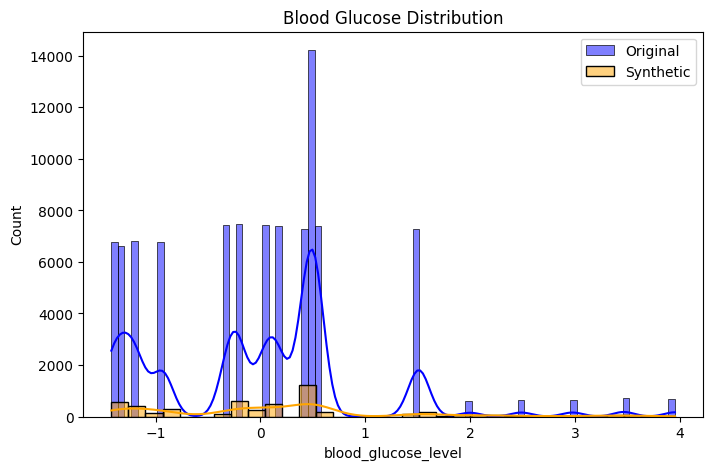

In [311]:
#Blood Glucose Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["blood_glucose_level"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["blood_glucose_level"],color="orange",label="Synthetic",kde=True)
plt.legend()
plt.title("Blood Glucose Distribution")
plt.savefig("blood_glucose_distribution.png")
plt.show()

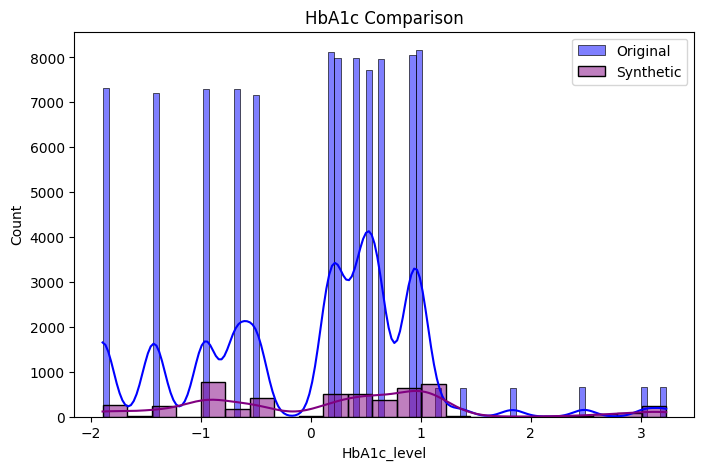

In [312]:
#HbA1c Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["HbA1c_level"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["HbA1c_level"],color="purple",label="Synthetic",kde=True)
plt.legend()
plt.title("HbA1c Comparison")
plt.savefig("hba1c_distribution.png")
plt.show()

In [313]:
#PCA Visualization
pca = PCA(n_components=2)

# Drop rows with NaN values before applying PCA
original_cleaned = original.dropna()
synthetic_cleaned = synthetic.dropna()

original_pca = pca.fit_transform(original_cleaned)

synthetic_pca = pca.transform(synthetic_cleaned)

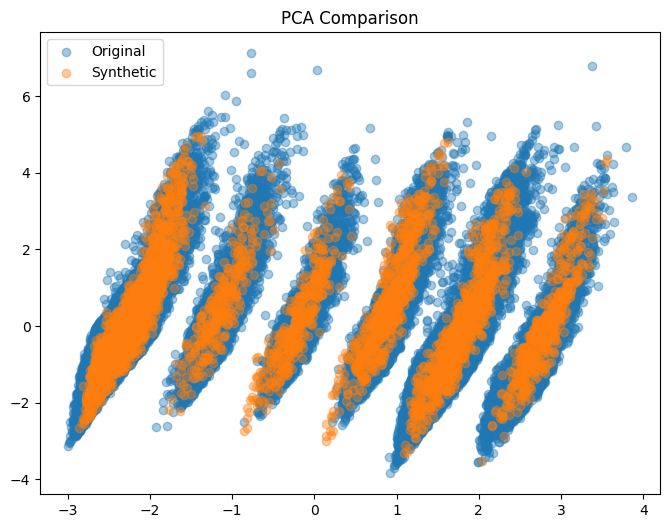

In [314]:
#Plot PCA
plt.figure(figsize=(8,6))

plt.scatter(original_pca[:,0],original_pca[:,1],alpha=0.4,label="Original")
plt.scatter(synthetic_pca[:,0],synthetic_pca[:,1],alpha=0.4,label="Synthetic")
plt.legend()
plt.title("PCA Comparison")
plt.savefig("PCA_plot.png")
plt.show()

In [316]:
#t-SNE Visualization
# Drop NaN values from synthetic data before sampling
synthetic_cleaned = synthetic.dropna()
combined = pd.concat([original.sample(500, random_state=42),synthetic_cleaned.sample(500, random_state=42)])
labels = ["Original"]*500 + ["Synthetic"]*500
tsne = TSNE(n_components=2,random_state=42)
tsne_result = tsne.fit_transform(combined)

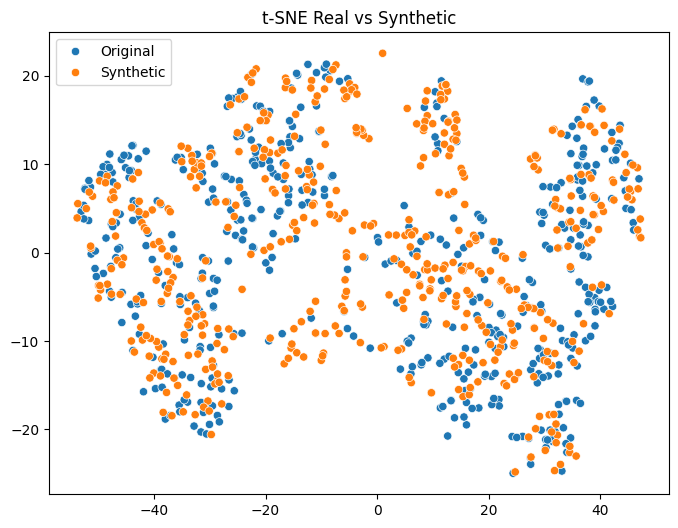

In [317]:
#Plot t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(x=tsne_result[:,0],y=tsne_result[:,1],hue=labels)
plt.title("t-SNE Real vs Synthetic")
plt.savefig("tsne_plot.png")
plt.show()

In [318]:
#Load Random Forest Model
model = joblib.load("random_forest.pkl")

In [320]:
#Feature Importance
importance = pd.DataFrame({"Feature":augmented.drop("diabetes",axis=1).columns,"Importance":model.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance

,Feature,Importance
6,HbA1c_level,0.509298
7,blood_glucose_level,0.366676
1,age,0.051043
5,bmi,0.030294
2,hypertension,0.022946
3,heart_disease,0.012966
4,smoking_history,0.004927
0,gender,0.001850


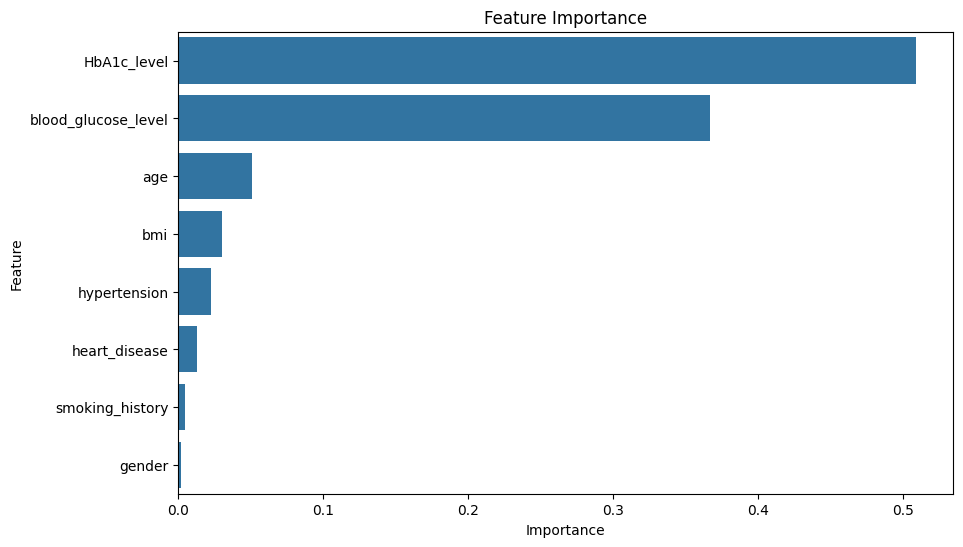

In [319]:
#Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

In [322]:
#Save Evaluation Summary
summary = pd.DataFrame({"Dataset":["Original","Synthetic","Augmented"],"Rows":[len(original),len(synthetic),len(augmented)],"Columns":[original.shape[1],synthetic.shape[1],augmented.shape[1]]})
summary


,Dataset,Rows,Columns
0,Original,96146,9
1,Synthetic,5000,9
2,Augmented,101146,9


In [350]:
#Save Summary
summary.to_csv("evaluation_summary.csv",index=False)

In [351]:
#Download All Graphs
from google.colab import files

files.download("original_heatmap.png")

files.download("synthetic_heatmap.png")

files.download("diabetes_distribution.png")

files.download("age_distribution.png")

files.download("bmi_distribution.png")

files.download("blood_glucose_distribution.png")

files.download("hba1c_distribution.png")

files.download("PCA_plot.png")

files.download("tsne_plot.png")

files.download("feature_importance.png")

files.download("evaluation_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [356]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import pickle
import joblib

# Page configuration
st.set_page_config(
    page_title="Healthcare AI Project",
    page_icon="🏥",
    layout="wide"
)

# Load trained Random Forest model

with open("random_forest_standard.pkl", "rb") as f:
    model = pickle.load(f)

scaler = joblib.load("scaler.pkl")

# Title
st.title("🏥 Healthcare Synthetic Data Project")

st.write(
    "Synthetic Medical Diagnosis Record Generation Using CTGAN"
)

st.divider()

# Project overview
st.header("📌 Project Overview")

st.write("""
This application demonstrates the generation of synthetic healthcare
data using CTGAN and diabetes prediction using a Random Forest
Machine Learning model.
""")

# Sidebar
st.sidebar.header("Patient Information")

gender = st.sidebar.selectbox(
    "Gender",
    ["Female", "Male", "Other"]
)

age = st.sidebar.number_input(
    "Age",
    min_value=0,
    max_value=100,
    value=40
)

hypertension = st.sidebar.selectbox(
    "Hypertension",
    [0, 1]
)

heart_disease = st.sidebar.selectbox(
    "Heart Disease",
    [0, 1]
)

smoking_history = st.sidebar.selectbox(
    "Smoking History",
    [
        "No Info",
        "current",
        "ever",
        "former",
        "never",
        "not current"
    ]
)

bmi = st.sidebar.number_input(
    "BMI",
    min_value=10.0,
    max_value=70.0,
    value=25.0
)

hba1c_level = st.sidebar.number_input(
    "HbA1c Level",
    min_value=3.0,
    max_value=10.0,
    value=5.5
)

blood_glucose_level = st.sidebar.number_input(
    "Blood Glucose Level",
    min_value=50.0,
    max_value=400.0,
    value=120.0
)

# Encoding categorical values
gender_mapping = {
    "Female": 0,
    "Male": 1,
    "Other": 2
}

smoking_mapping = {
    "No Info": 0,
    "current": 1,
    "ever": 2,
    "former": 3,
    "never": 4,
    "not current": 5
}

gender_encoded = gender_mapping[gender]

smoking_encoded = smoking_mapping[smoking_history]

# Prediction section
st.header("🔍 Diabetes Prediction")

if st.button("Predict Diabetes Risk"):

    input_data = pd.DataFrame({
        "gender": [gender_encoded],
        "age": [age],
        "hypertension": [hypertension],
        "heart_disease": [heart_disease],
        "smoking_history": [smoking_encoded],
        "bmi": [bmi],
        "HbA1c_level": [hba1c_level],
        "blood_glucose_level": [blood_glucose_level]
    })

    # Scale numerical features
    input_data[["age", "bmi", "HbA1c_level", "blood_glucose_level"]] = scaler.transform(
    input_data[["age", "bmi", "HbA1c_level", "blood_glucose_level"]]
)

    prediction = model.predict(input_data)

    st.write("Input after preprocessing")
    st.dataframe(input_data)

    probability = model.predict_proba(input_data)

    diabetes_probability = probability[0][1] * 100

    st.subheader("Prediction Result")

    if prediction[0] == 1:

        st.error(
            "⚠️ Model Prediction: Diabetes Risk Detected"
        )

    else:

        st.success(
            "✅ Model Prediction: No Diabetes Risk Detected"
        )

    st.metric(
        "Predicted Diabetes Probability",
        f"{diabetes_probability:.2f}%"
    )

    st.warning(
        "This application is for educational and research purposes only "
        "and should not be used as a medical diagnosis."
    )

Overwriting streamlit_app.py


In [357]:
!ls

age_distribution.png		 original_heatmap.png
augmented_dataset.csv		 PCA_plot.png
blood_glucose_distribution.png	 random_forest.pkl
bmi_distribution.png		 random_forest.pkl.gz
clean_diabetes_dataset.csv	 random_forest_standard.pkl
ctgan_model.pkl			 sample_data
diabetes_distribution.png	 scaler.pkl
diabetes_prediction_dataset.csv  smoking_encoder.pkl
evaluation_summary.csv		 streamlit_app.py
feature_importance.png		 synthetic_heatmap.png
gender_encoder.pkl		 synthetic_patient_data.csv
hba1c_distribution.png		 tsne_plot.png


In [358]:
from google.colab import files
files.download("streamlit_app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [359]:
sample = X_test_aug.iloc[[0]]

print(sample)

print("Prediction:", rf_augmented.predict(sample))
print("Probability:", rf_augmented.predict_proba(sample))

       gender       age  hypertension  heart_disease  smoking_history  \
67334       1  0.765962             1              0                4   

            bmi  HbA1c_level  blood_glucose_level  
67334  0.610038    -0.962154            -0.934213  
Prediction: [0]
Probability: [[0.99775785 0.00224215]]


### Conclusion

This project successfully demonstrated the application of Generative AI for generating synthetic medical diagnosis records in the healthcare domain.

The project began with exploratory data analysis and preprocessing of a diabetes healthcare dataset. The dataset was cleaned, duplicate records were removed, and categorical features were converted into numerical representations.

A CTGAN (Conditional Tabular Generative Adversarial Network) model was then trained on the cleaned healthcare dataset. The trained model successfully generated synthetic patient records that followed similar patterns and distributions to the original dataset.

The quality of the generated synthetic data was evaluated using statistical analysis, distribution comparisons, correlation heatmaps, and dimensionality reduction techniques such as PCA. The synthetic data was then combined with the original dataset to create an augmented dataset.

A Random Forest classification model was trained using both the original and augmented datasets. The model performance was evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and a Confusion Matrix.

Overall, this project demonstrates that CTGAN can be used as a Generative AI technique for generating synthetic tabular healthcare data and supporting machine learning experimentation and data augmentation.

Synthetic healthcare data can be useful for research, model development, testing, and educational purposes. However, it should not be directly used for clinical diagnosis or patient treatment without proper clinical validation, privacy assessment, ethical review, and regulatory approval.

This project provided practical experience in Generative AI, synthetic data generation, healthcare data analysis, machine learning, model evaluation, and end-to-end AI/ML project development.